# Data preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import geopandas as gpd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# datasets
sd_gid2021 = pd.read_csv("data/get_it_done_requests_closed_2021_datasd.csv")
sd_gid2022 = pd.read_csv("data/get_it_done_requests_closed_2022_datasd.csv")
sd_gid2023 = pd.read_csv("data/get_it_done_requests_closed_2023_datasd.csv")
sd_gid2024 = pd.read_csv("data/get_it_done_requests_closed_2024_datasd.csv")
sd_gid2025 = pd.read_csv("data/get_it_done_requests_closed_2025_datasd.csv")
#sd_gid2026 = pd.read_csv("data/get_it_done_requests_closed_2026_datasd.csv")


gid = pd.concat([sd_gid2021, sd_gid2022, sd_gid2023, sd_gid2024, sd_gid2025])


# get lengths of datasets
#print(f"Training data: {len(sd_gid_train)} \nTesting data: {len(sd_gid_test)}")

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_73559/828302681.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  sd_gid2021 = pd.read_csv("data/get_it_done_requests_closed_2021_datasd.csv")


In [3]:
gid.head()

,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
0,100123,NaN,4.030000e+10,2016-08-17T16:40:00,1654.0,TSW,Pavement Maintenance,CONCRETE PAVEMENT REPAIR ISSUE,2021-02-26,Closed,...,NaN,5.0,31.0,Rancho Bernardo,NaN,Web,NaN,SS-020515-PV1,SS-020515,We have a cement street it is buckling and one...
1,100191,87204.0,NaN,2016-08-17T23:48:00,1842.0,TSW,Pavement Maintenance,Evaluate for Resurfacing/Slurry,2021-09-02,Closed,...,NaN,5.0,3.0,Carmel Mountain Ranch,NaN,Web,NaN,NaN,SS-022700,Potholes and uneven pavement throughout Rancho...
2,100194,NaN,4.030001e+10,2016-08-18T04:17:00,1652.0,TSW,Pavement Maintenance,DAMAGED CURB,2021-02-25,Closed,...,NaN,2.0,6.0,Clairemont Mesa,NaN,Web,NaN,SS-014744-PV1,SS-014744,"curb cracked, please fill\ngutter joint depres..."
3,100241,NaN,4.030001e+10,2016-08-18T09:23:00,1751.0,TSW,Stormwater,DRAIN INLET,2021-06-04,Closed,...,NaN,3.0,19.0,Mission Valley,NaN,Email,NaN,IN22626,43802117,BRUSH AND OTHER DEBRIS IN DRAIN - REQUEST REMOVAL
4,100867,NaN,4.030000e+10,2016-08-21T12:19:00,1838.0,TSW,Pavement Maintenance,EVALUATE FOR RESURFACING/SLURRY,2021-09-02,Closed,...,NaN,9.0,57.0,Mid-City:Eastern Area,NaN,Mobile,NaN,SS-026868-PV1,SS-026868,This road needs To be repaired immediately


In [4]:
gid.columns

Index(['service_request_id', 'service_request_parent_id',
       'sap_notification_number', 'date_requested', 'case_age_days',
       'case_record_type', 'service_name', 'service_name_detail',
       'date_closed', 'status', 'lat', 'lng', 'street_address', 'zipcode',
       'council_district', 'comm_plan_code', 'comm_plan_name', 'park_name',
       'case_origin', 'referred', 'iamfloc', 'floc', 'public_description'],
      dtype='object')

## Preprocessing, largely copied from JACK

In [5]:
# copied from JACK
# filter negative case_age_days
gid_clean = gid[gid['case_age_days'] >= 0]

# log transform cage_age_days
gid_clean['log_case_age_days'] = np.log(gid_clean['case_age_days'])

gid = gid_clean
gid.head()

/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_73559/2161957657.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gid_clean['log_case_age_days'] = np.log(gid_clean['case_age_days'])


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description,log_case_age_days
0,100123,NaN,4.030000e+10,2016-08-17T16:40:00,1654.0,TSW,Pavement Maintenance,CONCRETE PAVEMENT REPAIR ISSUE,2021-02-26,Closed,...,5.0,31.0,Rancho Bernardo,NaN,Web,NaN,SS-020515-PV1,SS-020515,We have a cement street it is buckling and one...,7.410952
1,100191,87204.0,NaN,2016-08-17T23:48:00,1842.0,TSW,Pavement Maintenance,Evaluate for Resurfacing/Slurry,2021-09-02,Closed,...,5.0,3.0,Carmel Mountain Ranch,NaN,Web,NaN,NaN,SS-022700,Potholes and uneven pavement throughout Rancho...,7.518607
2,100194,NaN,4.030001e+10,2016-08-18T04:17:00,1652.0,TSW,Pavement Maintenance,DAMAGED CURB,2021-02-25,Closed,...,2.0,6.0,Clairemont Mesa,NaN,Web,NaN,SS-014744-PV1,SS-014744,"curb cracked, please fill\ngutter joint depres...",7.409742
3,100241,NaN,4.030001e+10,2016-08-18T09:23:00,1751.0,TSW,Stormwater,DRAIN INLET,2021-06-04,Closed,...,3.0,19.0,Mission Valley,NaN,Email,NaN,IN22626,43802117,BRUSH AND OTHER DEBRIS IN DRAIN - REQUEST REMOVAL,7.467942
4,100867,NaN,4.030000e+10,2016-08-21T12:19:00,1838.0,TSW,Pavement Maintenance,EVALUATE FOR RESURFACING/SLURRY,2021-09-02,Closed,...,9.0,57.0,Mid-City:Eastern Area,NaN,Mobile,NaN,SS-026868-PV1,SS-026868,This road needs To be repaired immediately,7.516433


In [6]:
# copied from JACK
# bin service_name
service_dict = {
    'graffiti': ['Graffiti - Public', 'Graffiti', 'Graffiti - Code Enforcement', 'Graffiti - Private'],
    'traffic': ['Traffic Signal Issue', 'Traffic Sign Maintenance', 'Traffic Signal Timing', 'Traffic Engineering'],
    'parking': ['Parking Violation', 'Parking', 'Oversized Vehicle'],
    'waste': ['Missed Collection', 'Trash/Recycling Collection', 'ESD Recycling', 'Illegal Dumping', 'Waste on Private Property', 'Dead Animal', 'Biohazard', 'Street Sweeping'],
    'infrastructure': ['Pothole', 'Pavement Maintenance', 'Sidewalk Repair Issue', 'ROW Maintenance', 'Street Flooded'],
    'environment': ['Tree Maintenance', 'Vegetation Encroachment', 'Weed Cleanup', 'Stormwater', 'Stormwater Code Enforcement', 'Parks Issue'],
    'lighting': ['Street Light Maintenance'],
    'code_enforcement': ['Environmental Services Code Compliance', 'Development Services - Code Enforcement', 'Right-of-Way Code Enforcement', 'PUD Code Compliance', 'STRO Violation'],
    'social_services': ['Encampment', 'Homeless Outreach'],
    'other': ['COVID-19', 'Other', 'Container Request', 'Shared Mobility Device', 'Bicycle-Related Issue']
}

def get_category(service):
    for category in service_dict:
        if service in service_dict[category]:
            return category
    return 'other'

gid['category'] = gid['service_name'].apply(get_category)

## Geotag the points

In [7]:
gid[['lat', 'lng']]

,lat,lng
0,33.046348,-117.050223
1,32.971346,-117.085739
2,32.796554,-117.197062
3,32.770891,-117.156253
4,32.754873,-117.078357
...,...,...
378597,32.726178,-117.164522
378598,32.745260,-117.181237
378599,32.773069,-117.252964
378600,32.765639,-117.105984


In [8]:
print(gid[['lat', 'lng']].head(10))
print(gid[['lat', 'lng']].isna().sum())
print(gid[['lat', 'lng']].dtypes)

         lat         lng
0  33.046348 -117.050223
1  32.971346 -117.085739
2  32.796554 -117.197062
3  32.770891 -117.156253
4  32.754873 -117.078357
5  32.555052 -116.988489
6  32.757081 -117.100795
7  32.956354 -117.225869
8  32.998129 -117.084256
9  32.684894 -117.027189
lat    7728
lng    7728
dtype: int64
lat    float64
lng    float64
dtype: object


In [9]:
# use coordinates
# drop na geometries b/c there weren't that many
gid_clean = gid.dropna(subset=['lat', 'lng'])
gid_gdf = gpd.GeoDataFrame(
    gid_clean, geometry=gpd.points_from_xy(gid_clean['lng'], gid_clean['lat'])
)

gid_gdf.set_crs(crs="EPSG:4326", inplace=True)
gid_gdf.head()


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description,log_case_age_days,category,geometry
0,100123,NaN,4.030000e+10,2016-08-17T16:40:00,1654.0,TSW,Pavement Maintenance,CONCRETE PAVEMENT REPAIR ISSUE,2021-02-26,Closed,...,Rancho Bernardo,NaN,Web,NaN,SS-020515-PV1,SS-020515,We have a cement street it is buckling and one...,7.410952,infrastructure,POINT (-117.05022 33.04635)
1,100191,87204.0,NaN,2016-08-17T23:48:00,1842.0,TSW,Pavement Maintenance,Evaluate for Resurfacing/Slurry,2021-09-02,Closed,...,Carmel Mountain Ranch,NaN,Web,NaN,NaN,SS-022700,Potholes and uneven pavement throughout Rancho...,7.518607,infrastructure,POINT (-117.08574 32.97135)
2,100194,NaN,4.030001e+10,2016-08-18T04:17:00,1652.0,TSW,Pavement Maintenance,DAMAGED CURB,2021-02-25,Closed,...,Clairemont Mesa,NaN,Web,NaN,SS-014744-PV1,SS-014744,"curb cracked, please fill\ngutter joint depres...",7.409742,infrastructure,POINT (-117.19706 32.79655)
3,100241,NaN,4.030001e+10,2016-08-18T09:23:00,1751.0,TSW,Stormwater,DRAIN INLET,2021-06-04,Closed,...,Mission Valley,NaN,Email,NaN,IN22626,43802117,BRUSH AND OTHER DEBRIS IN DRAIN - REQUEST REMOVAL,7.467942,environment,POINT (-117.15625 32.77089)
4,100867,NaN,4.030000e+10,2016-08-21T12:19:00,1838.0,TSW,Pavement Maintenance,EVALUATE FOR RESURFACING/SLURRY,2021-09-02,Closed,...,Mid-City:Eastern Area,NaN,Mobile,NaN,SS-026868-PV1,SS-026868,This road needs To be repaired immediately,7.516433,infrastructure,POINT (-117.07836 32.75487)


In [10]:
print(len(gid_gdf)) 

1942231


In [11]:
print("Invalid:", (~gid_gdf.geometry.is_valid).sum())
print("Empty:", gid_gdf.geometry.is_empty.sum())
print("NA: ", gid_gdf.geometry.isna().sum())

Invalid: 0
Empty: 0
NA:  0


<Axes: >

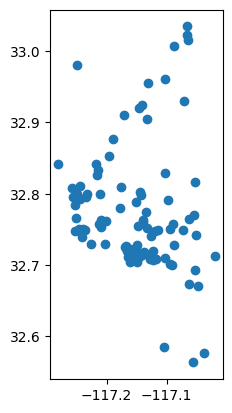

In [12]:
# randomly sample some points to plot
sample_reports = gid_gdf.sample(n=100)
sample_reports.plot()

## Join with census data

In [13]:
sd_tracts = gpd.read_file("data/Census_Tract_Tiger_2020_shapefile/Census_Tract_Tiger_2020.shp")
sd_tracts.head()

,objectid,statefp,countyfp,tractce,geoid,name,namelsad,mtfcc,funcstat,aland,awater,intptlat,intptlon,globalid,shape_Leng,shape_Area,geometry
0,1,06,073,020811,06073020811,208.11,Census Tract 208.11,G5020,S,47998881.0,0.0,+33.0026703,-116.7739397,{995907C9-5AC1-4EB1-A087-FC28DABFB834},131119.390173,5.166234e+08,"POLYGON ((6379376.507 1943417.493, 6379447.237..."
1,2,06,073,010015,06073010015,100.15,Census Tract 100.15,G5020,S,40475325.0,0.0,+32.5601548,-116.9530008,{300B9C7E-3B47-4EC1-B696-F59D265AF523},141215.190488,4.357099e+08,"POLYGON ((6317530.28 1784124.401, 6317539.03 1..."
2,3,06,073,020810,06073020810,208.10,Census Tract 208.10,G5020,S,39012365.0,0.0,+33.0348018,-116.7876255,{5C048ACA-56E4-475E-BD89-3C4717B76D6F},145531.170901,4.198968e+08,"POLYGON ((6372659.735 1947839.497, 6372660.833..."
3,4,06,073,021900,06073021900,219,Census Tract 219,G5020,S,5953517.0,3548500.0,+32.6650174,-117.1159847,{19F8FAC0-8673-47FD-95FC-FB0CCB24B44E},48071.798157,1.022829e+08,"POLYGON ((6288582.214 1827787.936, 6289210.494..."
4,5,06,073,020026,06073020026,200.26,Census Tract 200.26,G5020,S,3803528.0,21736.0,+33.1292602,-117.1882353,{649348E0-2FAE-48AF-A85D-329ECC77F340},44977.215739,4.117143e+07,"POLYGON ((6266733.386 1991154.753, 6266934.938..."


In [16]:
print(sd_tracts.crs)

EPSG:2230


In [18]:
# reproject to the sd_tracts crs (California Zone 6)
gid_gdf = gid_gdf.to_crs(sd_tracts.crs)
gid_gdf.crs


<Projected CRS: EPSG:2230>
Name: NAD83 / California zone 6 (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - California - counties Imperial; Orange; Riverside; San Diego.
- bounds: (-118.15, 32.53, -114.42, 34.08)
Coordinate Operation:
- name: SPCS83 California zone 6 (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [19]:
# spatial join with reports
gid_tracts = gid_gdf.sjoin(sd_tracts[['tractce', 'geometry']], how="left", predicate="intersects")
print(gid_tracts.shape[0])
gid_tracts.head()

1942231


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,case_origin,referred,iamfloc,floc,public_description,log_case_age_days,category,geometry,index_right,tractce
0,100123,NaN,4.030000e+10,2016-08-17T16:40:00,1654.0,TSW,Pavement Maintenance,CONCRETE PAVEMENT REPAIR ISSUE,2021-02-26,Closed,...,Web,NaN,SS-020515-PV1,SS-020515,We have a cement street it is buckling and one...,7.410952,infrastructure,POINT (6316453.7 1961431.576),247.0,017060
1,100191,87204.0,NaN,2016-08-17T23:48:00,1842.0,TSW,Pavement Maintenance,Evaluate for Resurfacing/Slurry,2021-09-02,Closed,...,Web,NaN,NaN,SS-022700,Potholes and uneven pavement throughout Rancho...,7.518607,infrastructure,POINT (6305352.148 1934228.395),535.0,017056
2,100194,NaN,4.030001e+10,2016-08-18T04:17:00,1652.0,TSW,Pavement Maintenance,DAMAGED CURB,2021-02-25,Closed,...,Web,NaN,SS-014744-PV1,SS-014744,"curb cracked, please fill\ngutter joint depres...",7.409742,infrastructure,POINT (6270633.411 1870925.259),592.0,009101
3,100241,NaN,4.030001e+10,2016-08-18T09:23:00,1751.0,TSW,Stormwater,DRAIN INLET,2021-06-04,Closed,...,Email,NaN,IN22626,43802117,BRUSH AND OTHER DEBRIS IN DRAIN - REQUEST REMOVAL,7.467942,environment,POINT (6283092.374 1861476.778),385.0,009308
4,100867,NaN,4.030000e+10,2016-08-21T12:19:00,1838.0,TSW,Pavement Maintenance,EVALUATE FOR RESURFACING/SLURRY,2021-09-02,Closed,...,Mobile,NaN,SS-026868-PV1,SS-026868,This road needs To be repaired immediately,7.516433,infrastructure,POINT (6306990.21 1855449.863),192.0,002702


In [20]:
gid_tracts = gid_tracts.drop(columns=['index_right'])

In [21]:
gid_tracts.to_file("modified_data/gid_tracts.gpkg")